## Imports

In [16]:
import pennylane as qml
import numpy as np
import random
import matplotlib.pyplot as plt

## Step 0. Settings

In [2]:
n_data = 9
n_anc = 8
n_qubits = n_data + n_anc

data_qubits = list(range(n_data))
anc_z = list(range(n_data, n_data + 4))
anc_x = list(range(n_data + 4, n_qubits))
print("Data qubits:", data_qubits)
print("Z stabilizer qubits:", anc_z)
print("X stabilizer qubits:", anc_x)

dev = qml.device("default.clifford", wires=n_qubits, tableau=False)

Data qubits: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Z stabilizer qubits: [9, 10, 11, 12]
X stabilizer qubits: [13, 14, 15, 16]


In [3]:
DATA_WIRES = data_qubits
ANC_WIRES = anc_z + anc_x

## Step 1. Stabilizer Preparation Block 정의

In [4]:
# 각 stabilizer가 어떤 data qubit에 연결되는지
X_stabilizers = [
    [0,1],
    [1,2,4,5],
    [3,4,6,7],
    [7,8]
]

Z_stabilizers = [
    [0,1,3,4],
    [2,5],
    [3,6],
    [4,5,7,8],
]

def measure_Z_stabilizer(anc, qubits):
    for q in qubits:
        qml.CNOT(wires=[q, anc])

def measure_X_stabilizer(anc, qubits):
    qml.Hadamard(wires=anc)
    for q in qubits:
        qml.CNOT(wires=[anc, q])
    qml.Hadamard(wires=anc)

In [5]:
def stabilizer_prep():
    for i, stab in enumerate(Z_stabilizers):
        qml.Barrier(wires=range(min(stab), anc_z[i]+1))
        measure_Z_stabilizer(anc_z[i], stab)
    for i, stab in enumerate(X_stabilizers):
        qml.Barrier(wires=range(min(stab), anc_x[i]+1))
        measure_X_stabilizer(anc_x[i], stab)

(<Figure size 4300x1800 with 1 Axes>, <Axes: >)

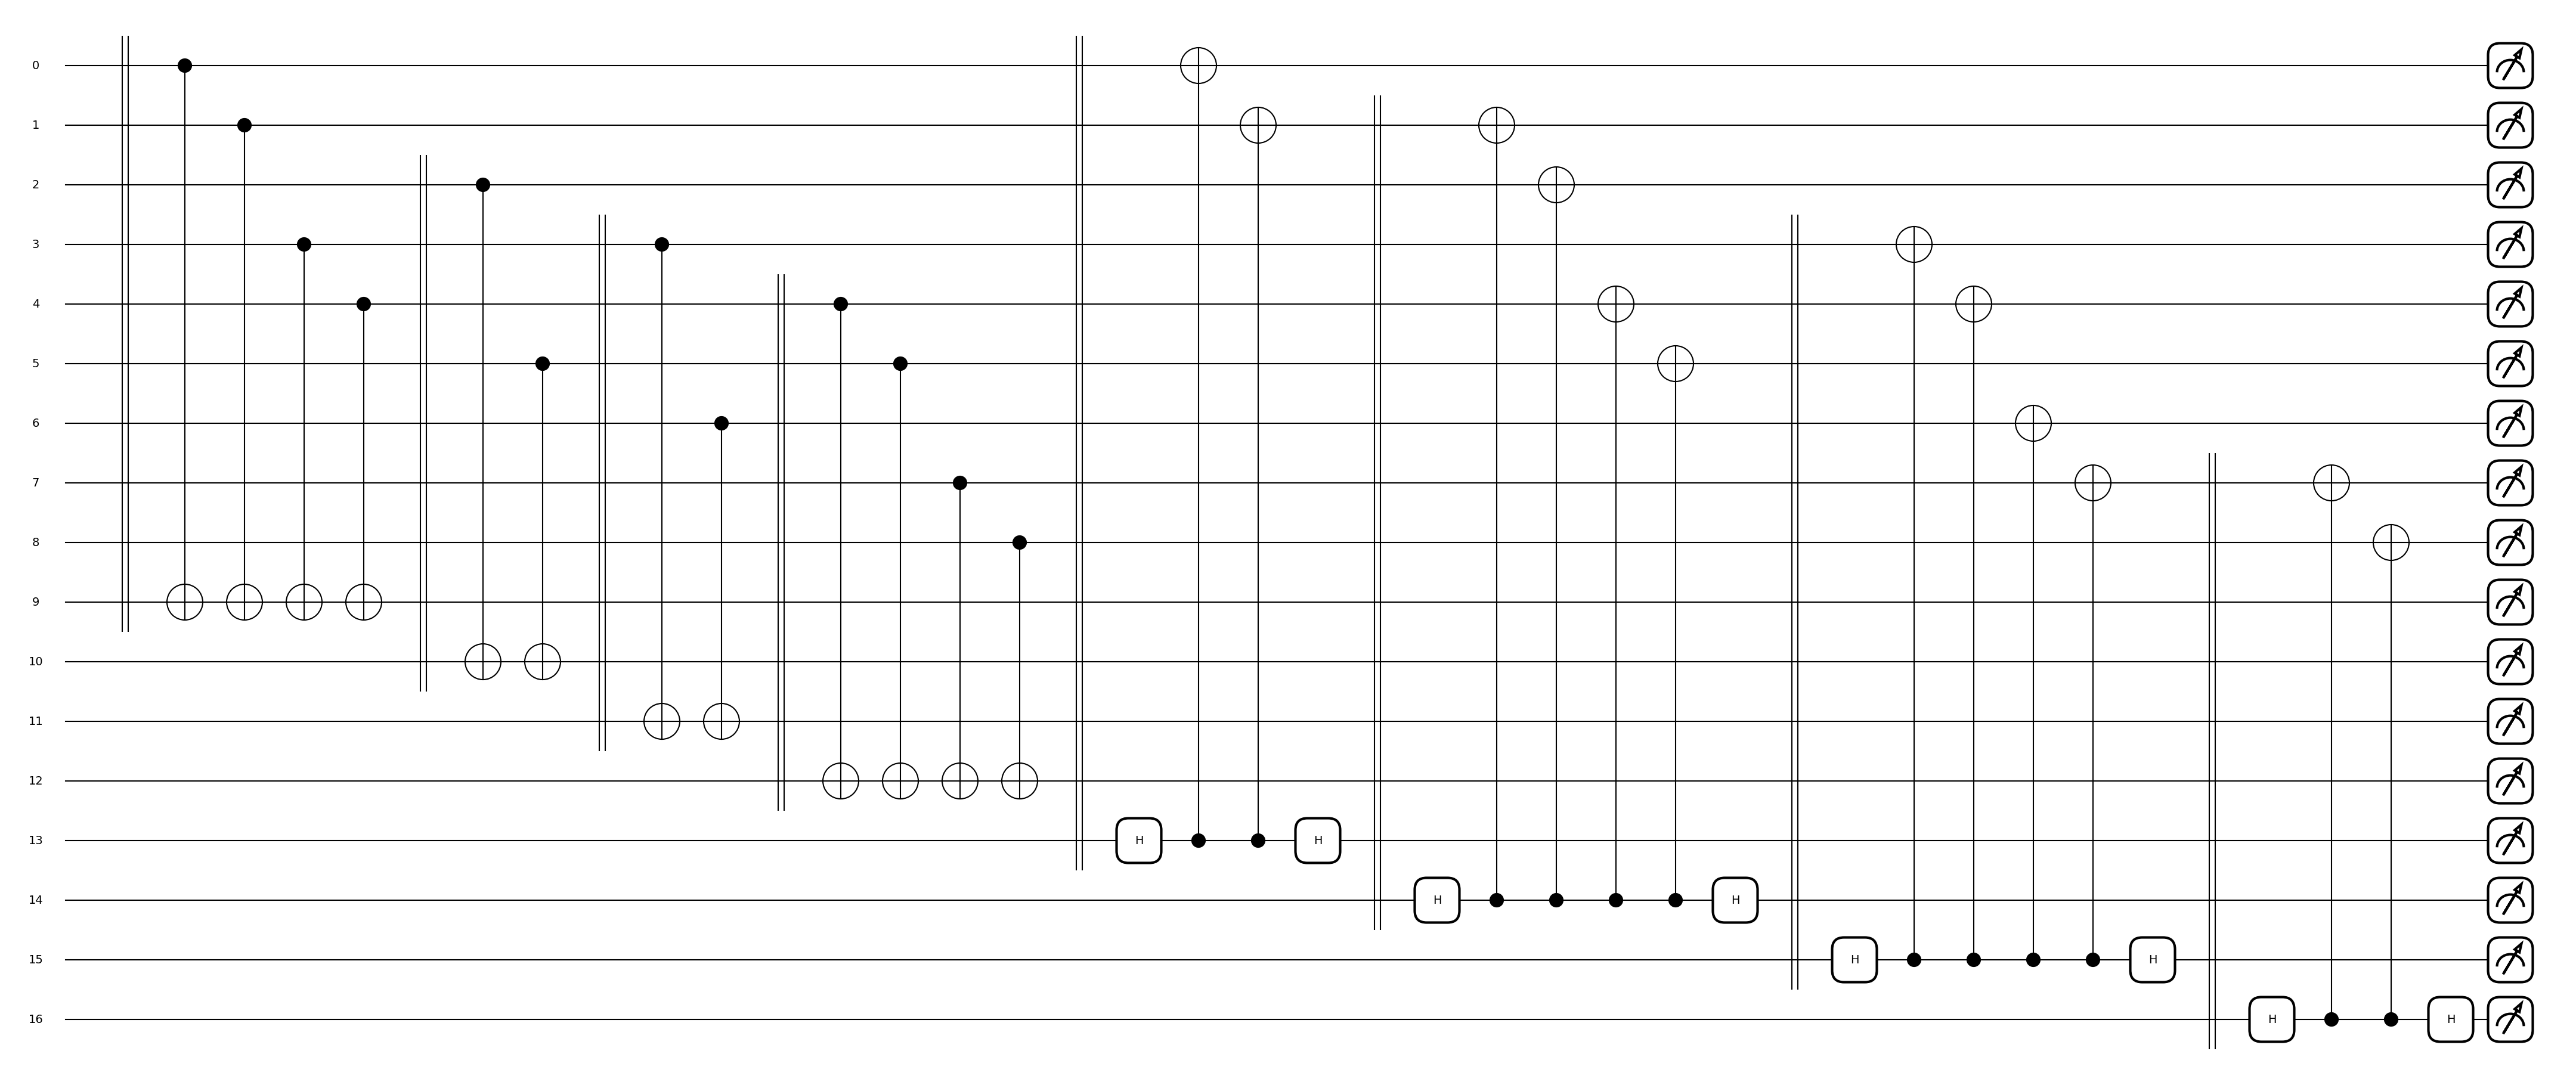

In [6]:
@qml.qnode(qml.device("default.qubit", wires=n_qubits))
def test_stabilizer_prep():
    stabilizer_prep()
    return qml.state()

qml.draw_mpl(test_stabilizer_prep, show_all_wires=True)()


## Step 2. logical state에 대해 syndrome 결과가 모두 0임을 확인

In [11]:
def prepare_logical_zero():
    """
    Prepare |0_L> of the d=3 rotated surface code
    with logical Z_L = Z0 Z1 Z2.
    """

    # Independent variables:
    # a -> qubit 0
    # b -> qubit 2
    # c -> qubit 3
    # d -> qubit 8
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=2)
    qml.Hadamard(wires=3)
    qml.Hadamard(wires=8)

    # q1 = a ⊕ b
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[2, 1])

    # q4 = b ⊕ c
    qml.CNOT(wires=[2, 4])
    qml.CNOT(wires=[3, 4])

    # q5 = b
    qml.CNOT(wires=[2, 5])

    # q6 = c
    qml.CNOT(wires=[3, 6])

    # q7 = c ⊕ d
    qml.CNOT(wires=[3, 7])
    qml.CNOT(wires=[8, 7])

In [12]:
@qml.qnode(qml.device("default.qubit", wires=n_qubits))
def test_prepare_logical_zero():
    prepare_logical_zero()
    stabilizer_prep()
    return qml.probs(wires=ANC_WIRES)

(<Figure size 5200x1800 with 1 Axes>, <Axes: >)

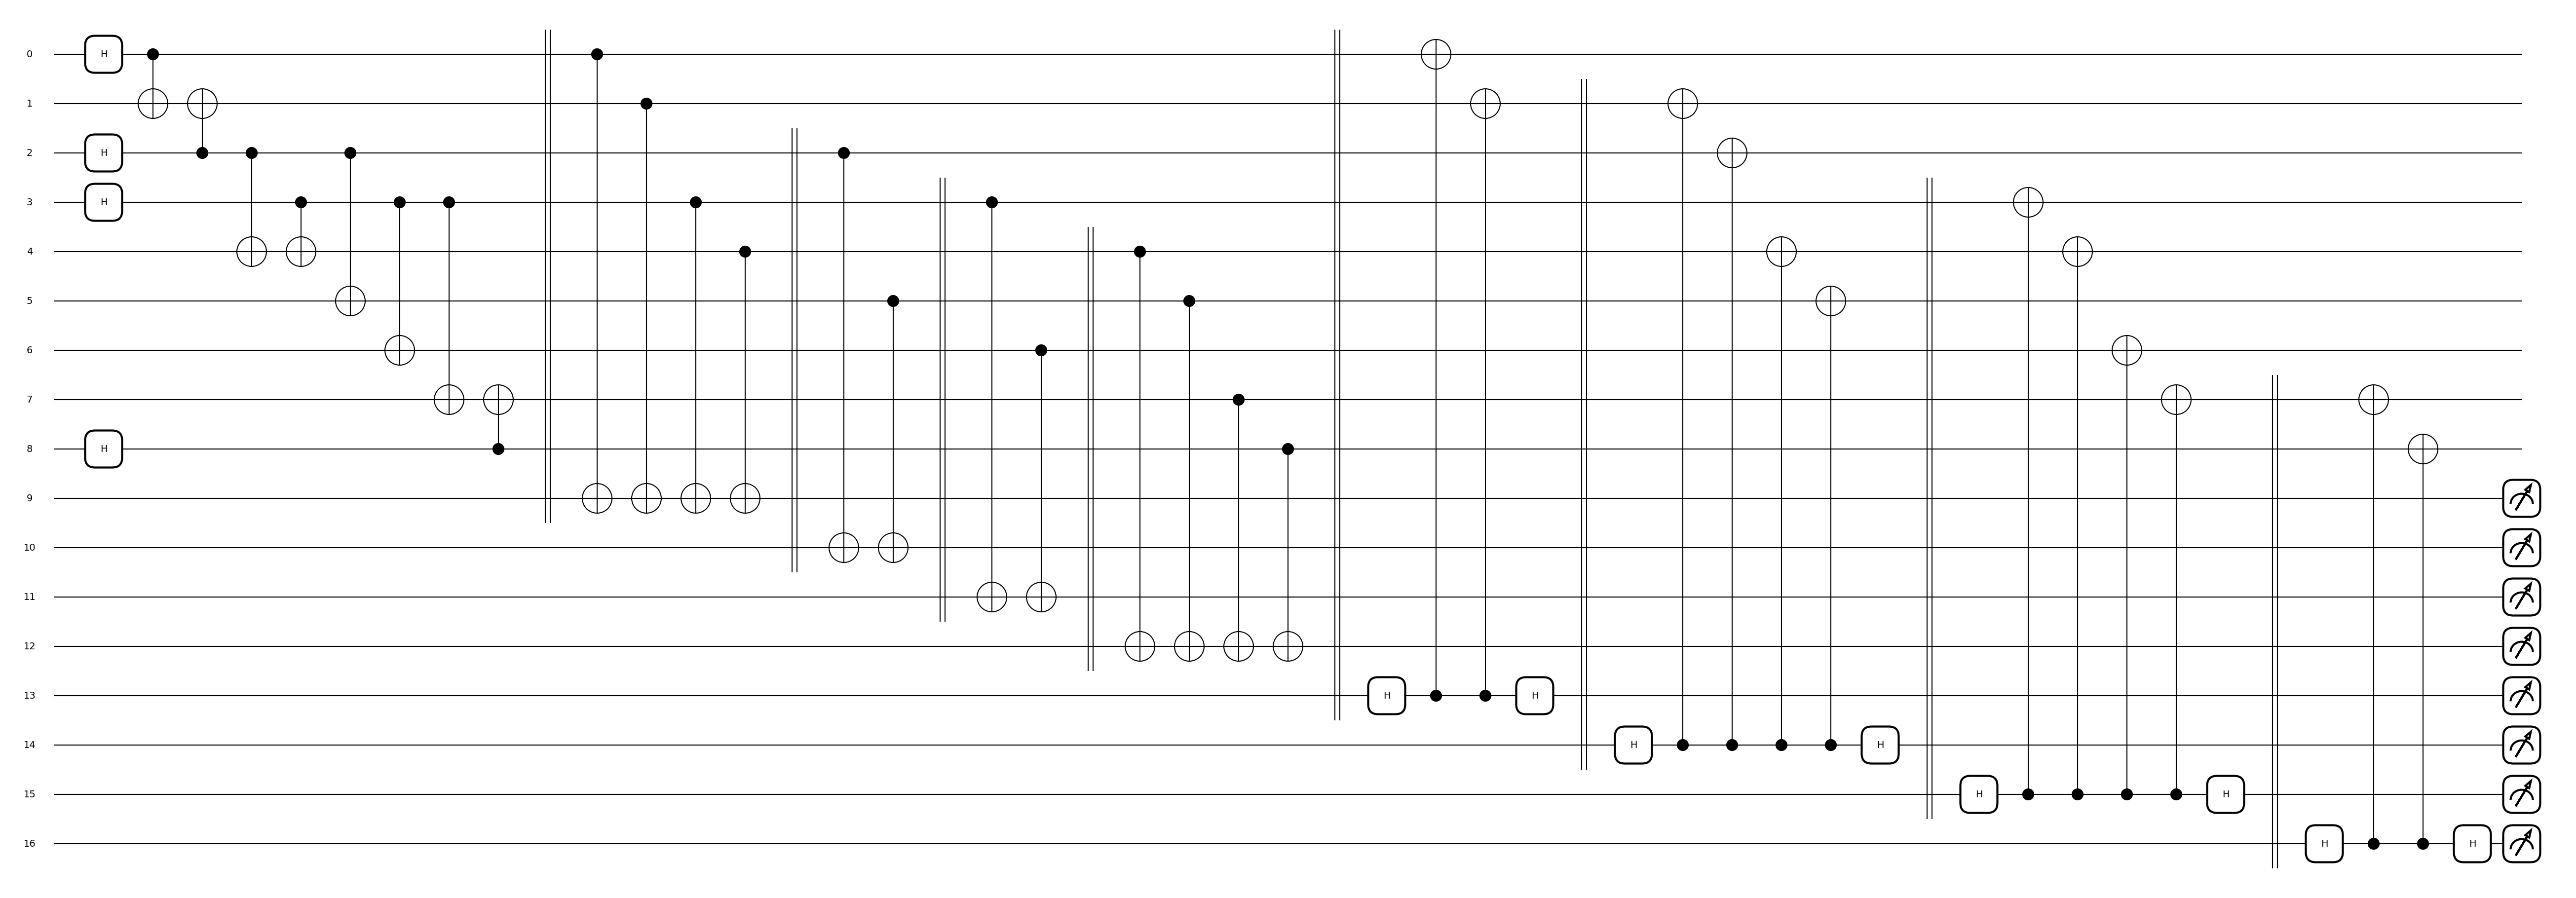

In [13]:
qml.draw_mpl(test_prepare_logical_zero, show_all_wires=True)()

Syndrome probabilities for |0_L>:


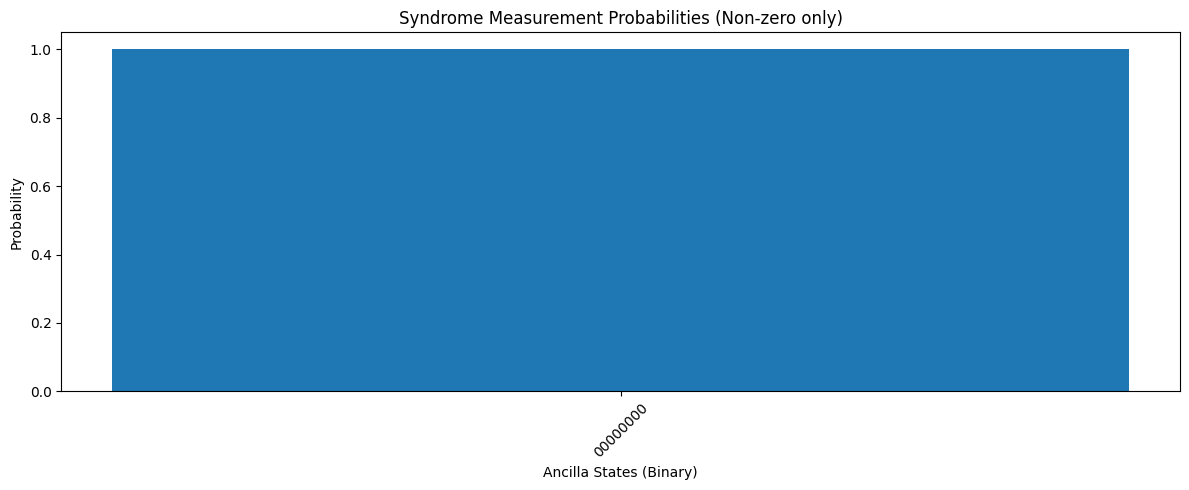

In [24]:
print("Syndrome probabilities for |0_L>:")
# probs_with_syndrome_for_logical_zero = test_prepare_logical_zero()

probs_with_syndrome_for_logical_zero = test_prepare_logical_zero()

import matplotlib.pyplot as plt

# Filter non-zero probabilities and convert indices to binary
non_zero_indices = [i for i, p in enumerate(probs_with_syndrome_for_logical_zero) if np.allclose(p, 0.0) == False]
non_zero_probs = [probs_with_syndrome_for_logical_zero[i] for i in non_zero_indices]
binary_labels = [format(i, '08b') for i in non_zero_indices]

plt.figure(figsize=(12, 5))
plt.bar(range(len(non_zero_probs)), non_zero_probs)
plt.xticks(range(len(non_zero_probs)), binary_labels, rotation=45)
plt.xlabel('Ancilla States (Binary)')
plt.ylabel('Probability')
plt.title('Syndrome Measurement Probabilities (Non-zero only)')
plt.tight_layout()
plt.show()

---

## Step 3. Pauli-X or Pauli-Z error에 따른 Error Detection 확인

In [69]:
def apply_pauli(type, wires):
    if type == 'X':
        qml.PauliX(wires=wires)
    elif type == 'Z':
        qml.PauliZ(wires=wires)

def apply_pauli_with_noise(type, wires, error_prob=0.0, error_type=None):
    if type == 'X':
        qml.PauliX(wires=wires)
    elif type == 'Z':
        qml.PauliZ(wires=wires)

In [71]:
def measure_Z_stabilizer_with_noise(anc, qubits, error_list = [], error_wires = [], error_prob=0.0):
    sorted_error_wires = sorted(error_wires)
    for q in qubits:
        qml.CNOT(wires=[q, anc])
        sorted_wires = sorted([q, anc])
        if sorted_wires == sorted_error_wires:
            if random.random() < error_prob:
                apply_pauli(error_list[0], wires=error_wires[0])
                apply_pauli(error_list[1], wires=error_wires[1])

def measure_X_stabilizer_with_noise(anc, qubits, error_list = [], error_wires = [], error_prob=0.0):
    sorted_error_wires = sorted(error_wires)
    qml.Hadamard(wires=anc)
    for q in qubits:
        qml.CNOT(wires=[anc, q])
        sorted_wires = sorted([anc, q])
        if sorted_wires == sorted_error_wires:
            if random.random() < error_prob:
                apply_pauli(error_list[0], wires=error_wires[0])
                apply_pauli(error_list[1], wires=error_wires[1])
    qml.Hadamard(wires=anc)

In [74]:
def stabilizer_prep_with_noise(error_type, error_wires, error_prob=0.0):
    for i, stab in enumerate(Z_stabilizers):
        qml.Barrier(wires=range(min(stab), anc_z[i]+1))
        measure_Z_stabilizer_with_noise(anc_z[i], stab, error_list=error_type, error_wires=error_wires, error_prob=error_prob)

    for i, stab in enumerate(X_stabilizers):
        qml.Barrier(wires=range(min(stab), anc_x[i]+1))
        measure_X_stabilizer_with_noise(anc_x[i], stab, error_list=error_type, error_wires=error_wires, error_prob=error_prob)

/Users/jhan/Desktop/KAIST/ETRI/연구/2026/2. Correlated Noise Estimation by Syndrome Measurement/Correlated-Noise-Estimation/syndrome_localenv/lib/python3.13/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


(<Figure size 5400x1800 with 1 Axes>, <Axes: >)

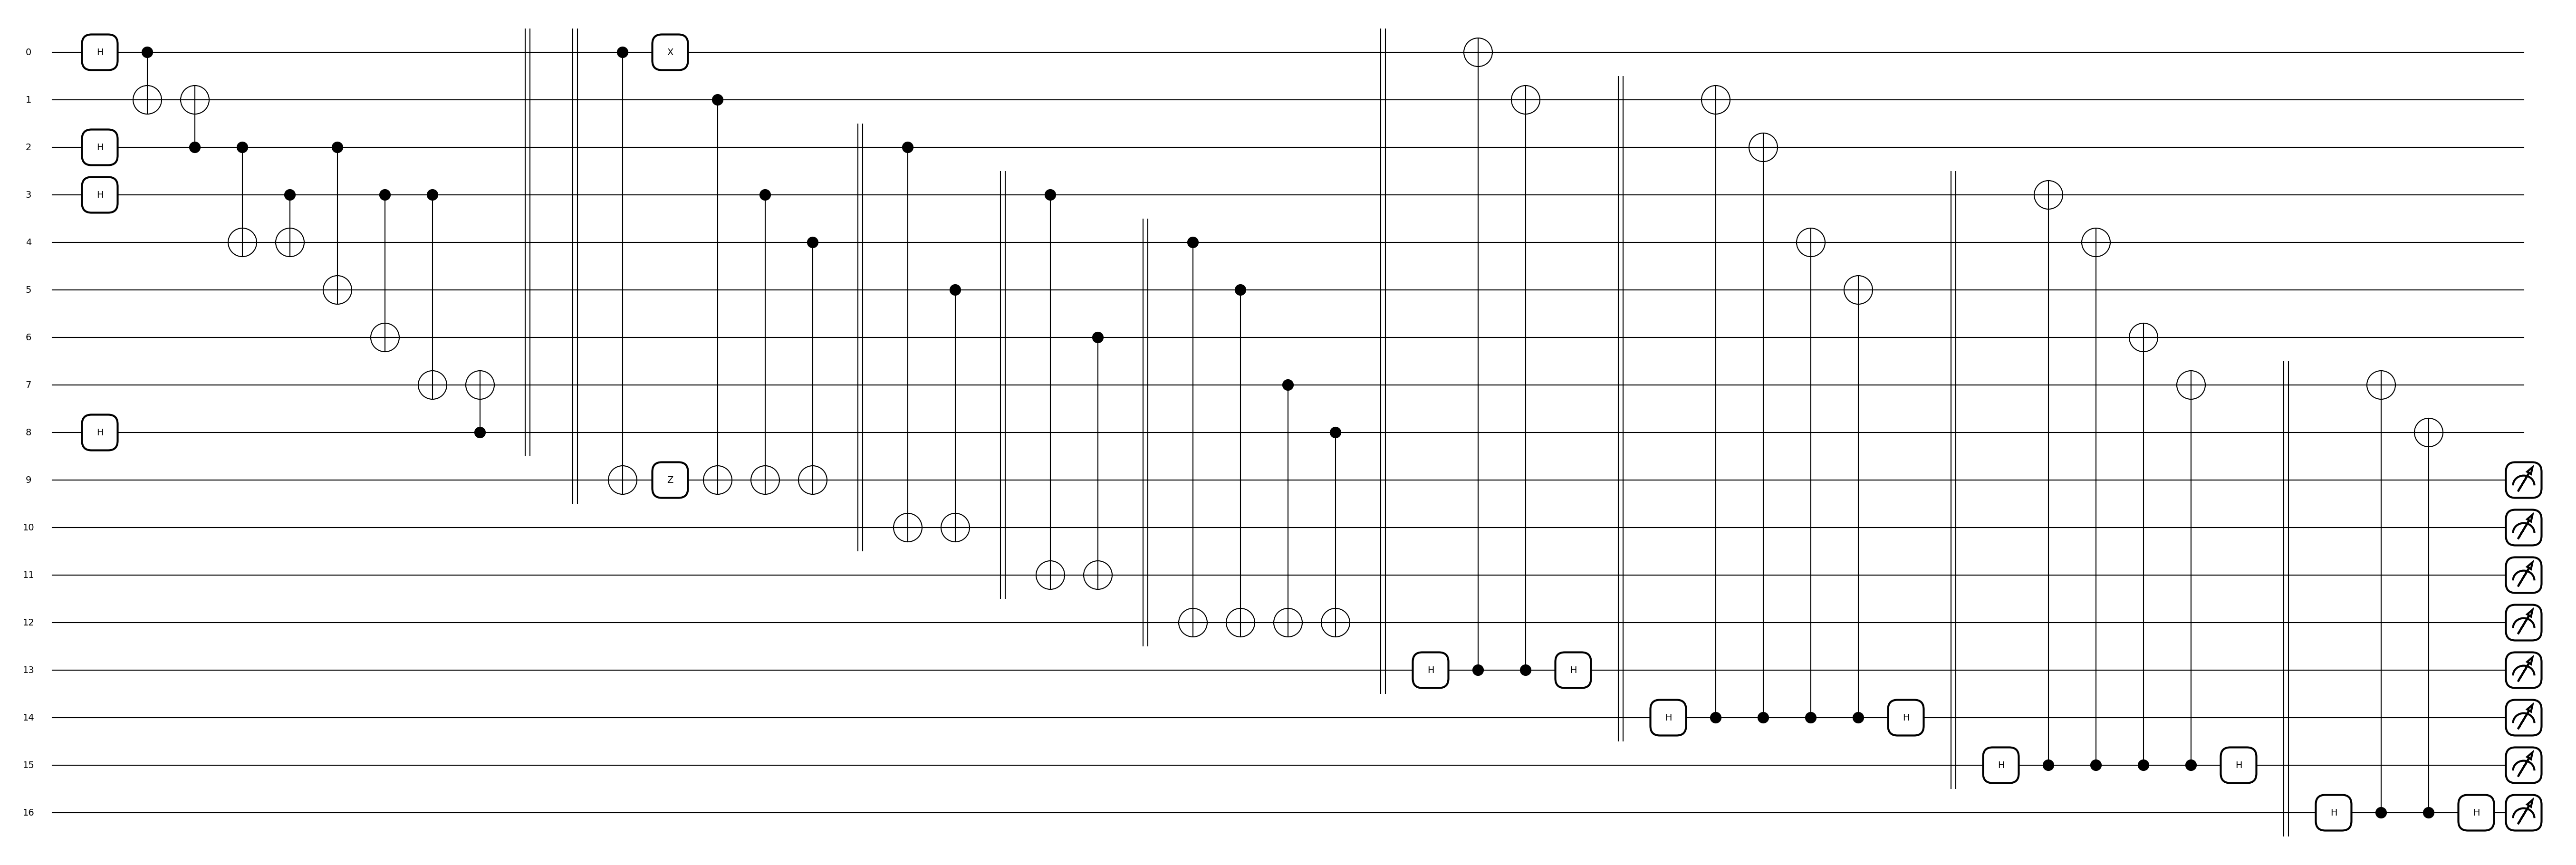

In [155]:
@qml.qnode(qml.device("default.qubit", wires=n_qubits, shots=1000))
def test_stabilizer_with_noise(error_type, error_wires, error_prob=0.0):
    prepare_logical_zero()
    qml.Barrier(wires=DATA_WIRES)
    for q in error_wires:
        apply_pauli(error_type, q)
    stabilizer_prep_with_noise(error_type, error_wires, error_prob=error_prob)
    return qml.probs(wires=ANC_WIRES)

qml.draw_mpl(test_stabilizer_with_noise, show_all_wires=True)(['X', 'Z'], [0, 9], error_prob=1.0)

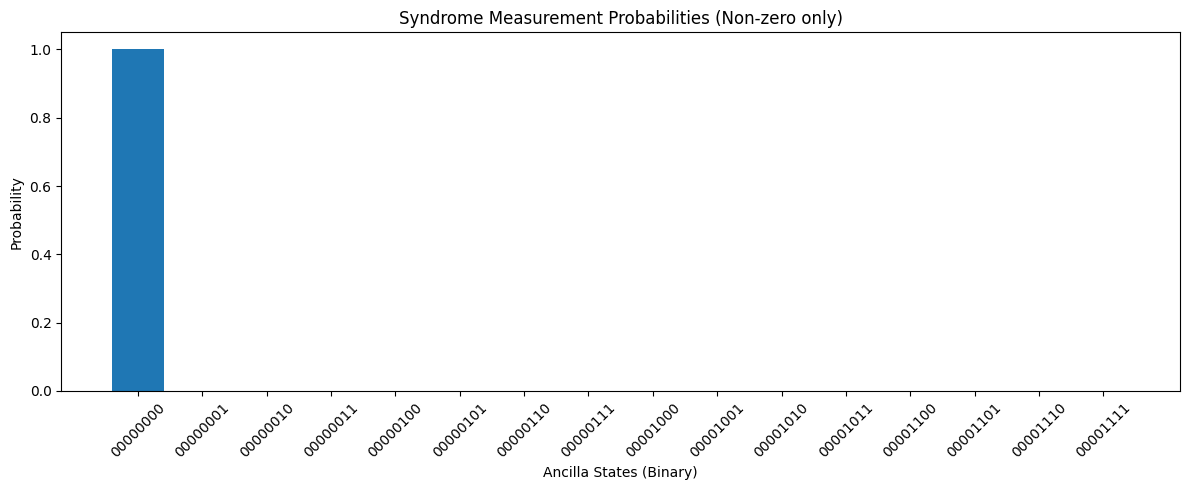

In [86]:
prob_output = test_stabilizer_with_noise(['X', 'Z'], [0, 10], error_prob=1.0)

import matplotlib.pyplot as plt

# Filter non-zero probabilities and convert indices to binary
non_zero_indices = [i for i, p in enumerate(prob_output) if p > 0]
non_zero_probs = [prob_output[i] for i in non_zero_indices]
binary_labels = [format(i, '08b') for i in non_zero_indices]

plt.figure(figsize=(12, 5))
plt.bar(range(len(non_zero_probs)), non_zero_probs)
plt.xticks(range(len(non_zero_probs)), binary_labels, rotation=45)
plt.xlabel('Ancilla States (Binary)')
plt.ylabel('Probability')
plt.title('Syndrome Measurement Probabilities (Non-zero only)')
plt.tight_layout()
plt.show()

## Step 4. Stabilizer 측정 반복에 대한 data 얻기

In [178]:
import pennylane as qml
import numpy as np
import random

# --------------------------------------------------
# Basic Pauli application
# --------------------------------------------------

def apply_pauli(pauli_type, wires):
    if pauli_type == 'X':
        qml.PauliX(wires=wires)
    elif pauli_type == 'Z':
        qml.PauliZ(wires=wires)
    elif pauli_type == 'Y':
        qml.PauliY(wires=wires)


def apply_two_qubit_pauli_error(error_list, error_wires):
    """
    error_list 예: ['X', 'Z']
    error_wires 예: [0, 9]
    """
    for p, w in zip(error_list, error_wires):
        apply_pauli(p, wires=w)


# --------------------------------------------------
# One stabilizer measurement with ancilla reset
# --------------------------------------------------

def measure_Z_stabilizer_with_noise_and_reset(
    anc,
    qubits,
    error_list=[],
    error_wires=[],
    error_prob=0.0,
):
    """
    Z stabilizer 측정.

    네 기존 코드와 동일하게:
        data q -> anc 로 CNOT
    """

    sorted_error_wires = sorted(error_wires)

    for q in qubits:
        qml.CNOT(wires=[q, anc])

        sorted_wires = sorted([q, anc])

        if sorted_wires == sorted_error_wires:
            if random.random() < error_prob:
                apply_two_qubit_pauli_error(error_list, error_wires)

    m = qml.measure(anc, reset=True)
    return m


def measure_X_stabilizer_with_noise_and_reset(
    anc,
    qubits,
    error_list=[],
    error_wires=[],
    error_prob=0.0,
):
    """
    X stabilizer 측정.

    네 기존 코드와 동일하게:
        H on anc
        anc -> data q 로 CNOT
        H on anc
    """

    sorted_error_wires = sorted(error_wires)

    qml.Hadamard(wires=anc)

    for q in qubits:
        qml.CNOT(wires=[anc, q])

        sorted_wires = sorted([anc, q])

        if sorted_wires == sorted_error_wires:
            if random.random() < error_prob:
                apply_two_qubit_pauli_error(error_list, error_wires)

    qml.Hadamard(wires=anc)

    m = qml.measure(anc, reset=True)
    return m


# --------------------------------------------------
# One full syndrome extraction round
# --------------------------------------------------

def syndrome_round_with_noise(
    error_list=[],
    error_wires=[],
    error_prob=0.0,
):
    """
    한 round에서 8개 syndrome 측정.

    순서:
        Z stabilizer 4개
        X stabilizer 4개

    반환:
        [z0, z1, z2, z3, x0, x1, x2, x3]
    """

    round_record = []

    for i, stab in enumerate(Z_stabilizers):
        m = measure_Z_stabilizer_with_noise_and_reset(
            anc=anc_z[i],
            qubits=stab,
            error_list=error_list,
            error_wires=error_wires,
            error_prob=error_prob,
        )
        round_record.append(m)

    for i, stab in enumerate(X_stabilizers):
        m = measure_X_stabilizer_with_noise_and_reset(
            anc=anc_x[i],
            qubits=stab,
            error_list=error_list,
            error_wires=error_wires,
            error_prob=error_prob,
        )
        round_record.append(m)

    return round_record


# --------------------------------------------------
# Repeated syndrome measurement QNode
# --------------------------------------------------

def make_repeated_syndrome_qnode(n_rounds, shots=1000):

    dev = qml.device("default.qubit", wires=n_qubits, shots=shots)

    @qml.qnode(dev)
    def repeated_syndrome_measurement(
        error_list=[],
        error_wires=[],
        error_prob=0.0,
        initial_error_list=[],
        initial_error_wires=[],
    ):
        measurement_record = []

        # logical |0_L> 준비
        prepare_logical_zero()

        qml.Barrier(wires=DATA_WIRES)

        # 초기 data error 또는 원하는 위치의 fixed error 삽입
        for p, w in zip(initial_error_list, initial_error_wires):
            apply_pauli(p, wires=w)

        # 반복 syndrome extraction
        for t in range(n_rounds):
            round_record = syndrome_round_with_noise(
                error_list=error_list,
                error_wires=error_wires,
                error_prob=error_prob,
            )

            measurement_record.extend(round_record)

        return [qml.sample(m) for m in measurement_record]

    return repeated_syndrome_measurement


In [180]:
# --------------------------------------------------
# Run and reshape
# --------------------------------------------------

n_rounds = 3
shots = 1

repeated_qnode = make_repeated_syndrome_qnode(n_rounds=n_rounds, shots=shots)

/Users/jhan/Desktop/KAIST/ETRI/연구/2026/2. Correlated Noise Estimation by Syndrome Measurement/Correlated-Noise-Estimation/syndrome_localenv/lib/python3.13/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


In [ ]:
raw = repeated_qnode(
    error_list=['X', 'Z'],
    error_wires=[0, 9],
    error_prob=1.0,
)

raw = np.array(raw)

print("raw shape:", raw.shape)
# expected: (n_rounds * 8, shots)

syndrome = raw.reshape(n_rounds, 8, shots)
syndrome = np.moveaxis(syndrome, 2, 0)

print("syndrome shape:", syndrome.shape)
# expected: (shots, n_rounds, 8)

# syndrome[shot, round, stabilizer_index]
print(syndrome[0])

raw shape: (16, 1000)
syndrome shape: (1000, 2, 8)
[[0 0 0 0 1 0 0 0]
 [1 0 0 0 0 0 0 0]]


In [177]:
for synd in syndrome:
    print(synd == syndrome[0])

[[ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]]
[[ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]]
[[ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]]
[[ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]]
[[ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]]
[[ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]]
[[ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]]
[[ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]]
[[ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]]
[[ True  True  True  True  True  True  True  True]
 [ True  True  True  T

## 외전. round 반복 측정 방법

In [160]:
import pennylane as qml
import numpy as np
from collections import defaultdict

shots = 20
T = 2

# wires
d0, d1, d2 = 0, 1, 2
a0, a1 = 3, 4

dev = qml.device("default.qubit", wires=5, shots=shots)

@qml.qnode(dev)
def repetition_3_two_rounds(error_round=None, error_qubit=None):
    measurements = defaultdict(list)

    for t in range(T):
        # optional data error before syndrome extraction
        if error_round == t and error_qubit is not None:
            qml.PauliX(error_qubit)

        # measure Z0 Z1 using a0
        qml.CNOT(wires=[d0, a0])
        qml.CNOT(wires=[d1, a0])

        # measure Z1 Z2 using a1
        qml.CNOT(wires=[d1, a1])
        qml.CNOT(wires=[d2, a1])

        m01 = qml.measure(a0, reset=True)
        measurements[t].append(m01)
        m12 = qml.measure(a1, reset=True)
        measurements[t].append(m12)

        qml.Barrier(wires=range(5))

    return [qml.sample(m) for m in measurements[0]], [qml.sample(m) for m in measurements[1]]


raw = repetition_3_two_rounds()

raw = np.array(raw)
print("raw shape:", raw.shape)
print(raw)

raw shape: (2, 2, 20)
[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]]


(<Figure size 2100x750 with 1 Axes>, <Axes: >)

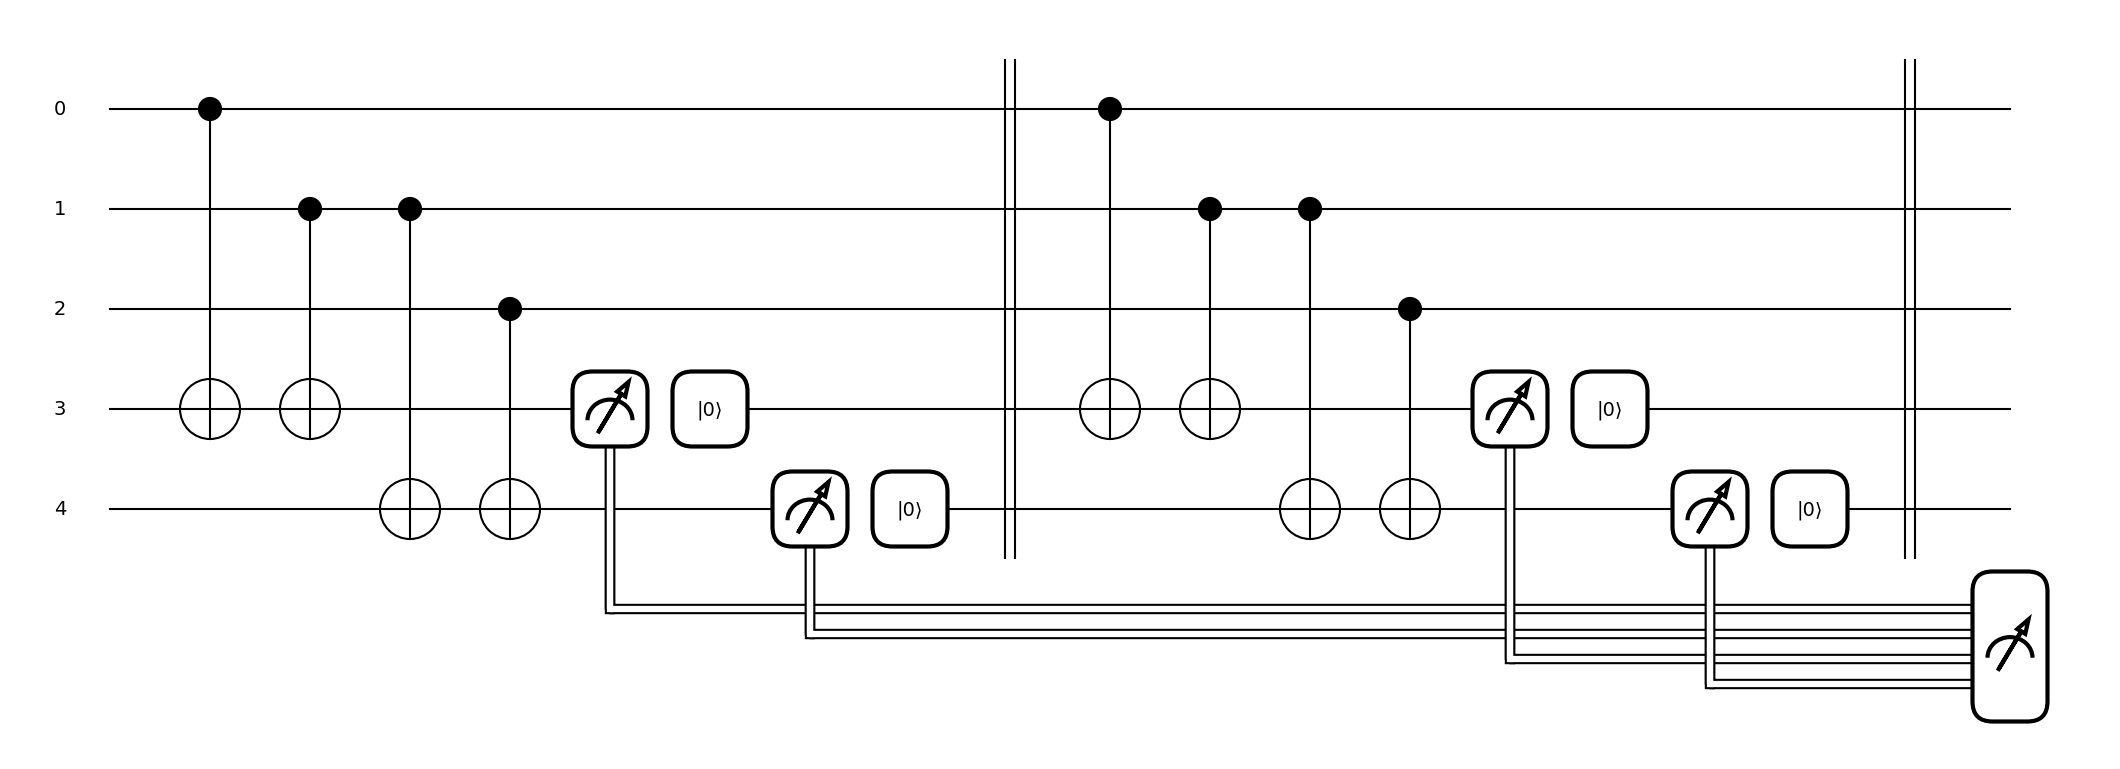

In [161]:
qml.draw_mpl(repetition_3_two_rounds, show_all_wires=True)()